# Trinity Football EPA Project - Analysis Script
The purpose of this script is to conduct analysis using the created epa model and its variables. This script will analyze offensive performance

# First Phase
Import the necessary packages and build the dataframe from the exported excel file.

In [1]:
import os
import re
import glob
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [4]:
excel_file = '/content/drive/MyDrive/TUFB_EPA/TUFB_EPA_Analysis_complete.xlsx'

df = pd.read_excel(excel_file)
df.head(10)

,play,odk,hash,dn,dist,yard_ln,gn_ls,result,play_type,personnel,off_form,motion,protection,off_play,blitz,def_front,def_stunt,coverage,form_tree,rb_gap_hit,series,o_line_scheme,film,cov_loaded_balanced,practice,pass_zone,team_name,opp_name,home_away,win,game_date,team_pts,opp_pts,explosive,off_series,def_series,drive_down,drive_points,yards_to_go,goal_to_go,points,game_id,point_differential,off_score,def_score,next_odk,turnover_on_downs,score_event,next_score,ep,epa
0,1.0,k,NaN,NaN,NaN,NaN,NaN,NaN,ko,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,TU,AC,H,1,02/06/2020,35,24,0,0,0,NaN,0,NaN,0,0,02/06/2020_AC_TU,0,35,24,d,0,0,7,NaN,NaN
1,2.0,d,L,1.0,10.0,-42.0,4.0,complete,pass,20,TWINS PRO,NaN,NaN,NaN,NaN,FIELD TITE,NaN,CHECK,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,AC,TU,H,1,02/06/2020,35,24,0,0,1,23.0,0,58.0,0,0,02/06/2020_AC_TU,0,35,24,d,0,0,7,2.590872,0.085068
2,3.0,d,R,2.0,6.0,-46.0,-2.0,rush,run,NaN,TRIPS NUB,NaN,NaN,NaN,KWIK,FIELD,NaN,COBRA,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,AC,TU,H,1,02/06/2020,35,24,0,0,1,2.0,0,54.0,0,0,02/06/2020_AC_TU,0,35,24,d,0,0,7,2.675940,-0.947247
3,4.0,d,R,3.0,8.0,-44.0,4.0,complete,pass,NaN,TRIPS NUB,NaN,NaN,NaN,RUSH,TEXAS,NaN,CHECK,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,AC,TU,H,1,02/06/2020,35,24,0,0,1,3.0,0,56.0,0,0,02/06/2020_AC_TU,0,35,24,k,0,0,7,1.728693,-1.728693
4,5.0,k,L,4.0,4.0,-48.0,NaN,NaN,punt rec,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,TU,AC,H,1,02/06/2020,35,24,0,0,0,4.0,0,52.0,0,0,02/06/2020_AC_TU,0,35,24,o,1,0,7,NaN,NaN
5,7.0,o,L,1.0,10.0,-15.0,14.0,complete,pass,THUNDER,KING LIZ,NaN,NaN,LAY B-SLING,NaN,NaN,NaN,NaN,2X2,NaN,2,PUSH ZONE,NaN,NaN,NaN,NaN,TU,AC,H,1,02/06/2020,35,24,0,1,0,23.0,3,85.0,0,0,02/06/2020_AC_TU,0,35,24,o,0,0,7,1.795311,0.202983
6,8.0,o,R,1.0,10.0,-29.0,-1.0,rush,run,ZEBRA,TREY LEFT,NaN,NaN,LAMBO BOY BOND,NaN,NaN,NaN,NaN,3X1,NaN,2,STRETCH ZONE,NaN,NaN,NaN,NaN,TU,AC,H,1,02/06/2020,35,24,0,1,0,1.0,3,71.0,0,0,02/06/2020_AC_TU,0,35,24,o,0,0,7,1.998294,-0.551048
7,9.0,o,L,2.0,11.0,-28.0,0.0,incomplete,pass,TIGER,RIGHT,NaN,Q3,PIN SMASH,NaN,NaN,NaN,NaN,2X2,NaN,2,SLIDE PASS PROTECTION,NaN,NaN,NaN,NaN,TU,AC,H,1,02/06/2020,35,24,0,1,0,2.0,3,72.0,0,0,02/06/2020_AC_TU,0,35,24,o,0,0,7,1.447245,-0.648118
8,10.0,o,L,3.0,11.0,-28.0,12.0,complete,pass,TIGER,FAR RIGHT,NaN,SPRINT RIGHT,FLOOD,NaN,NaN,NaN,NaN,3X1,NaN,2,SPRINT OUT,NaN,NaN,NaN,NaN,TU,AC,H,1,02/06/2020,35,24,0,1,0,3.0,3,72.0,0,0,02/06/2020_AC_TU,0,35,24,o,0,0,7,0.799127,1.624452
9,11.0,o,R,1.0,10.0,-40.0,1.0,rush,run,THUNDER,QUEEN RIP,NaN,NaN,LION GOPHER,NaN,NaN,NaN,NaN,2X2,NaN,2,DUO,NaN,NaN,NaN,NaN,TU,AC,H,1,02/06/2020,35,24,0,1,0,1.0,3,60.0,0,0,02/06/2020_AC_TU,0,35,24,o,0,0,7,2.423579,-0.348949


# Data Reshaping
Reshape necessary columns to be utilized in analysis

In [5]:
# =========================
# RESHAPE NAMING COLUMNS
# =========================

# When odk == "o", team_name = filename_team (first in filename)
# Grab that stable value per game and broadcast it to all rows
game_names = (
    df[df["odk"] == "o"]
    .groupby("game_id")[["team_name", "opp_name"]]
    .first()
    .reset_index()
)

df = df.drop(columns=["team_name", "opp_name"])
df = df.merge(game_names, on="game_id", how="left")

df.head(10)

,play,odk,hash,dn,dist,yard_ln,gn_ls,result,play_type,personnel,off_form,motion,protection,off_play,blitz,def_front,def_stunt,coverage,form_tree,rb_gap_hit,series,o_line_scheme,film,cov_loaded_balanced,practice,pass_zone,home_away,win,game_date,team_pts,opp_pts,explosive,off_series,def_series,drive_down,drive_points,yards_to_go,goal_to_go,points,game_id,point_differential,off_score,def_score,next_odk,turnover_on_downs,score_event,next_score,ep,epa,team_name,opp_name
0,1.0,k,NaN,NaN,NaN,NaN,NaN,NaN,ko,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,H,1,02/06/2020,35,24,0,0,0,NaN,0,NaN,0,0,02/06/2020_AC_TU,0,35,24,d,0,0,7,NaN,NaN,TU,AC
1,2.0,d,L,1.0,10.0,-42.0,4.0,complete,pass,20,TWINS PRO,NaN,NaN,NaN,NaN,FIELD TITE,NaN,CHECK,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,H,1,02/06/2020,35,24,0,0,1,23.0,0,58.0,0,0,02/06/2020_AC_TU,0,35,24,d,0,0,7,2.590872,0.085068,TU,AC
2,3.0,d,R,2.0,6.0,-46.0,-2.0,rush,run,NaN,TRIPS NUB,NaN,NaN,NaN,KWIK,FIELD,NaN,COBRA,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,H,1,02/06/2020,35,24,0,0,1,2.0,0,54.0,0,0,02/06/2020_AC_TU,0,35,24,d,0,0,7,2.675940,-0.947247,TU,AC
3,4.0,d,R,3.0,8.0,-44.0,4.0,complete,pass,NaN,TRIPS NUB,NaN,NaN,NaN,RUSH,TEXAS,NaN,CHECK,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,H,1,02/06/2020,35,24,0,0,1,3.0,0,56.0,0,0,02/06/2020_AC_TU,0,35,24,k,0,0,7,1.728693,-1.728693,TU,AC
4,5.0,k,L,4.0,4.0,-48.0,NaN,NaN,punt rec,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,H,1,02/06/2020,35,24,0,0,0,4.0,0,52.0,0,0,02/06/2020_AC_TU,0,35,24,o,1,0,7,NaN,NaN,TU,AC
5,7.0,o,L,1.0,10.0,-15.0,14.0,complete,pass,THUNDER,KING LIZ,NaN,NaN,LAY B-SLING,NaN,NaN,NaN,NaN,2X2,NaN,2,PUSH ZONE,NaN,NaN,NaN,NaN,H,1,02/06/2020,35,24,0,1,0,23.0,3,85.0,0,0,02/06/2020_AC_TU,0,35,24,o,0,0,7,1.795311,0.202983,TU,AC
6,8.0,o,R,1.0,10.0,-29.0,-1.0,rush,run,ZEBRA,TREY LEFT,NaN,NaN,LAMBO BOY BOND,NaN,NaN,NaN,NaN,3X1,NaN,2,STRETCH ZONE,NaN,NaN,NaN,NaN,H,1,02/06/2020,35,24,0,1,0,1.0,3,71.0,0,0,02/06/2020_AC_TU,0,35,24,o,0,0,7,1.998294,-0.551048,TU,AC
7,9.0,o,L,2.0,11.0,-28.0,0.0,incomplete,pass,TIGER,RIGHT,NaN,Q3,PIN SMASH,NaN,NaN,NaN,NaN,2X2,NaN,2,SLIDE PASS PROTECTION,NaN,NaN,NaN,NaN,H,1,02/06/2020,35,24,0,1,0,2.0,3,72.0,0,0,02/06/2020_AC_TU,0,35,24,o,0,0,7,1.447245,-0.648118,TU,AC
8,10.0,o,L,3.0,11.0,-28.0,12.0,complete,pass,TIGER,FAR RIGHT,NaN,SPRINT RIGHT,FLOOD,NaN,NaN,NaN,NaN,3X1,NaN,2,SPRINT OUT,NaN,NaN,NaN,NaN,H,1,02/06/2020,35,24,0,1,0,3.0,3,72.0,0,0,02/06/2020_AC_TU,0,35,24,o,0,0,7,0.799127,1.624452,TU,AC
9,11.0,o,R,1.0,10.0,-40.0,1.0,rush,run,THUNDER,QUEEN RIP,NaN,NaN,LION GOPHER,NaN,NaN,NaN,NaN,2X2,NaN,2,DUO,NaN,NaN,NaN,NaN,H,1,02/06/2020,35,24,0,1,0,1.0,3,60.0,0,0,02/06/2020_AC_TU,0,35,24,o,0,0,7,2.423579,-0.348949,TU,AC


# Create Trinity Dataframe
Create dataframe focusing on Trinity to use for analysis.

In [6]:
# =========================
# CREATE TU DATAFRAME
# =========================

tu_df = df[df['team_name'] == 'TU'].sort_values(['game_id', 'play']).reset_index(drop=True)
tu_df.head(10)

,play,odk,hash,dn,dist,yard_ln,gn_ls,result,play_type,personnel,off_form,motion,protection,off_play,blitz,def_front,def_stunt,coverage,form_tree,rb_gap_hit,series,o_line_scheme,film,cov_loaded_balanced,practice,pass_zone,home_away,win,game_date,team_pts,opp_pts,explosive,off_series,def_series,drive_down,drive_points,yards_to_go,goal_to_go,points,game_id,point_differential,off_score,def_score,next_odk,turnover_on_downs,score_event,next_score,ep,epa,team_name,opp_name
0,1.0,k,NaN,NaN,NaN,NaN,NaN,NaN,ko,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,H,1,02/06/2020,35,24,0,0,0,NaN,0,NaN,0,0,02/06/2020_AC_TU,0,35,24,d,0,0,7,NaN,NaN,TU,AC
1,2.0,d,L,1.0,10.0,-42.0,4.0,complete,pass,20,TWINS PRO,NaN,NaN,NaN,NaN,FIELD TITE,NaN,CHECK,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,H,1,02/06/2020,35,24,0,0,1,23.0,0,58.0,0,0,02/06/2020_AC_TU,0,35,24,d,0,0,7,2.590872,0.085068,TU,AC
2,3.0,d,R,2.0,6.0,-46.0,-2.0,rush,run,NaN,TRIPS NUB,NaN,NaN,NaN,KWIK,FIELD,NaN,COBRA,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,H,1,02/06/2020,35,24,0,0,1,2.0,0,54.0,0,0,02/06/2020_AC_TU,0,35,24,d,0,0,7,2.675940,-0.947247,TU,AC
3,4.0,d,R,3.0,8.0,-44.0,4.0,complete,pass,NaN,TRIPS NUB,NaN,NaN,NaN,RUSH,TEXAS,NaN,CHECK,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,H,1,02/06/2020,35,24,0,0,1,3.0,0,56.0,0,0,02/06/2020_AC_TU,0,35,24,k,0,0,7,1.728693,-1.728693,TU,AC
4,5.0,k,L,4.0,4.0,-48.0,NaN,NaN,punt rec,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,H,1,02/06/2020,35,24,0,0,0,4.0,0,52.0,0,0,02/06/2020_AC_TU,0,35,24,o,1,0,7,NaN,NaN,TU,AC
5,7.0,o,L,1.0,10.0,-15.0,14.0,complete,pass,THUNDER,KING LIZ,NaN,NaN,LAY B-SLING,NaN,NaN,NaN,NaN,2X2,NaN,2,PUSH ZONE,NaN,NaN,NaN,NaN,H,1,02/06/2020,35,24,0,1,0,23.0,3,85.0,0,0,02/06/2020_AC_TU,0,35,24,o,0,0,7,1.795311,0.202983,TU,AC
6,8.0,o,R,1.0,10.0,-29.0,-1.0,rush,run,ZEBRA,TREY LEFT,NaN,NaN,LAMBO BOY BOND,NaN,NaN,NaN,NaN,3X1,NaN,2,STRETCH ZONE,NaN,NaN,NaN,NaN,H,1,02/06/2020,35,24,0,1,0,1.0,3,71.0,0,0,02/06/2020_AC_TU,0,35,24,o,0,0,7,1.998294,-0.551048,TU,AC
7,9.0,o,L,2.0,11.0,-28.0,0.0,incomplete,pass,TIGER,RIGHT,NaN,Q3,PIN SMASH,NaN,NaN,NaN,NaN,2X2,NaN,2,SLIDE PASS PROTECTION,NaN,NaN,NaN,NaN,H,1,02/06/2020,35,24,0,1,0,2.0,3,72.0,0,0,02/06/2020_AC_TU,0,35,24,o,0,0,7,1.447245,-0.648118,TU,AC
8,10.0,o,L,3.0,11.0,-28.0,12.0,complete,pass,TIGER,FAR RIGHT,NaN,SPRINT RIGHT,FLOOD,NaN,NaN,NaN,NaN,3X1,NaN,2,SPRINT OUT,NaN,NaN,NaN,NaN,H,1,02/06/2020,35,24,0,1,0,3.0,3,72.0,0,0,02/06/2020_AC_TU,0,35,24,o,0,0,7,0.799127,1.624452,TU,AC
9,11.0,o,R,1.0,10.0,-40.0,1.0,rush,run,THUNDER,QUEEN RIP,NaN,NaN,LION GOPHER,NaN,NaN,NaN,NaN,2X2,NaN,2,DUO,NaN,NaN,NaN,NaN,H,1,02/06/2020,35,24,0,1,0,1.0,3,60.0,0,0,02/06/2020_AC_TU,0,35,24,o,0,0,7,2.423579,-0.348949,TU,AC


In [7]:
tu_df.tail(100)

,play,odk,hash,dn,dist,yard_ln,gn_ls,result,play_type,personnel,off_form,motion,protection,off_play,blitz,def_front,def_stunt,coverage,form_tree,rb_gap_hit,series,o_line_scheme,film,cov_loaded_balanced,practice,pass_zone,home_away,win,game_date,team_pts,opp_pts,explosive,off_series,def_series,drive_down,drive_points,yards_to_go,goal_to_go,points,game_id,point_differential,off_score,def_score,next_odk,turnover_on_downs,score_event,next_score,ep,epa,team_name,opp_name
12086,70.0,d,NaN,1.0,10.0,-25.0,0.0,incomplete,pass,11,TWINS,NaN,NaN,DBP,NaN,FIELD SHADE FAY,NaN,CHECK,NaN,NaN,10,NaN,NaN,NaN,NaN,NaN,H,1,11/29/2025,34,24,0,0,5,23.0,7,75.0,0,0,11/29/2025_HSU_TU,13,34,24,d,0,0,7,1.544192,-0.467159,TU,HSU
12087,71.0,d,NaN,2.0,10.0,-25.0,9.0,complete,pass,11,TWINS FIB,NaN,NaN,DBP,NaN,FIELD,NaN,CHECK,NaN,NaN,10,NaN,NaN,NaN,NaN,NaN,H,1,11/29/2025,34,24,0,0,5,2.0,7,75.0,0,0,11/29/2025_HSU_TU,13,34,24,d,0,0,7,1.077034,0.547459,TU,HSU
12088,72.0,d,NaN,3.0,1.0,-34.0,8.0,rush,run,11,TWINS NASTY FIB,NaN,NaN,INSERT,NaN,FIELD SHADE FAY,NaN,CHECK,NaN,NaN,10,NaN,NaN,NaN,NaN,NaN,H,1,11/29/2025,34,24,0,0,5,3.0,7,66.0,0,0,11/29/2025_HSU_TU,13,34,24,d,0,0,7,1.624493,0.529833,TU,HSU
12089,73.0,d,NaN,1.0,10.0,-42.0,-1.0,complete,pass,11,TWINS,NaN,NaN,SCREEN,NaN,FIELD SHADE FAY,ROPE,CHECK,NaN,NaN,10,NaN,NaN,NaN,NaN,NaN,H,1,11/29/2025,34,24,0,0,5,1.0,7,58.0,0,0,11/29/2025_HSU_TU,13,34,24,d,0,0,7,2.154326,-0.580364,TU,HSU
12090,74.0,d,NaN,2.0,11.0,-41.0,39.0,complete,pass,11,TWINS,NaN,NaN,DBP,KWIK X,FIELD,NaN,SKY,NaN,NaN,10,NaN,NaN,NaN,NaN,NaN,H,1,11/29/2025,34,24,1,0,5,2.0,7,59.0,0,0,11/29/2025_HSU_TU,13,34,24,d,0,0,7,1.573962,2.345986,TU,HSU
12091,75.0,d,NaN,1.0,10.0,20.0,5.0,rush,run,11,TWINS,NaN,NaN,INSERT,NaN,FIELD SHADE FAY,NaN,CHECK,NaN,NaN,10,NaN,NaN,NaN,NaN,NaN,H,1,11/29/2025,34,24,0,0,5,1.0,7,20.0,0,0,11/29/2025_HSU_TU,13,34,24,d,0,0,7,3.919947,0.121132,TU,HSU
12092,76.0,d,NaN,2.0,5.0,15.0,0.0,timeout,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,NaN,NaN,H,1,11/29/2025,34,24,0,0,5,2.0,7,15.0,0,0,11/29/2025_HSU_TU,13,34,24,d,0,0,7,4.041079,-0.648118,TU,HSU
12093,77.0,d,NaN,3.0,5.0,15.0,15.0,"complete, td",pass,11,TWINS,NaN,NaN,PAP,NaN,FIELD TITE,NaN,CHECK,NaN,NaN,10,NaN,NaN,NaN,NaN,NaN,H,1,11/29/2025,34,24,0,0,5,3.0,7,15.0,0,-6,11/29/2025_HSU_TU,7,34,24,k,0,7,3,3.392961,3.607039,TU,HSU
12094,78.0,k,NaN,1.0,NaN,3.0,NaN,good,extra pt. block,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,H,1,11/29/2025,34,24,0,0,0,0.0,0,3.0,0,-1,11/29/2025_HSU_TU,6,34,24,k,0,0,3,NaN,NaN,TU,HSU
12095,79.0,k,NaN,1.0,NaN,-35.0,0.0,touchback,ko rec,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,H,1,11/29/2025,34,24,0,0,0,0.0,0,65.0,0,0,11/29/2025_HSU_TU,6,34,24,o,0,0,3,NaN,NaN,TU,HSU


In [8]:
tu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12186 entries, 0 to 12185
Data columns (total 51 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   play                 12186 non-null  float64
 1   odk                  12149 non-null  object 
 2   hash                 8956 non-null   object 
 3   dn                   11928 non-null  float64
 4   dist                 11226 non-null  float64
 5   yard_ln              11936 non-null  float64
 6   gn_ls                10901 non-null  float64
 7   result               11495 non-null  object 
 8   play_type            11924 non-null  object 
 9   personnel            9244 non-null   object 
 10  off_form             9627 non-null   object 
 11  motion               1612 non-null   object 
 12  protection           2129 non-null   object 
 13  off_play             8472 non-null   object 
 14  blitz                1353 non-null   object 
 15  def_front            5751 non-null  

# Analysis Visualizations
Analyze offensive trends and performance using visualization.

EPA by Down Visualization

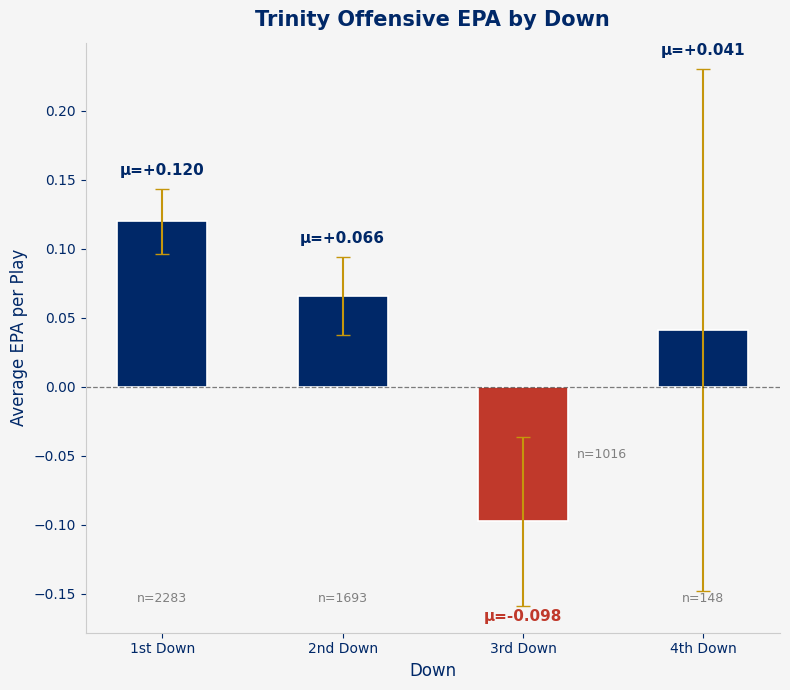

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter: TU offensive plays with valid EPA
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna())
].copy()

# Colors
TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'

# Aggregate by down
down_df = (
    off_df[off_df['dn'].isin([1, 2, 3, 4])]
    .groupby('dn')['epa']
    .agg(['mean', 'sem', 'count'])
    .reset_index()
)
down_df['dn_label'] = down_df['dn'].map({1: '1st Down', 2: '2nd Down', 3: '3rd Down', 4: '4th Down'})

# Plot
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

bars = ax.bar(
    down_df['dn_label'],
    down_df['mean'],
    color=[TU_BLUE if v >= 0 else '#C0392B' for v in down_df['mean']],
    edgecolor='white',
    linewidth=1.2,
    width=0.5,
    yerr=down_df['sem'],
    capsize=5,
    error_kw={'ecolor': TU_GOLD, 'linewidth': 1.5}
)

ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)

for bar, row in zip(bars, down_df.itertuples()):
    error_top    = row.mean + row.sem
    error_bottom = row.mean - row.sem

    if row.mean >= 0:
        label_y = error_top + 0.008
        va      = 'bottom'
    else:
        label_y = error_bottom - 0.002
        va      = 'top'

    ax.text(
        bar.get_x() + bar.get_width() / 2, label_y,
        f'μ={row.mean:+.3f}',
        ha='center', va=va, fontsize=11, fontweight='bold',
        color=TU_BLUE if row.mean >= 0 else '#C0392B'
    )

    # Place n= to the side for negative bars, bottom for positive
    if row.mean >= 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2, ax.get_ylim()[0] + 0.02,
            f'n={row.count}',
            ha='center', va='bottom', fontsize=9, color='gray'
        )
    else:
        ax.text(
            bar.get_x() + bar.get_width() + 0.05, row.mean / 2,
            f'n={row.count}',
            ha='left', va='center', fontsize=9, color='gray'
        )

ax.set_title('Trinity Offensive EPA by Down', fontsize=15, fontweight='bold', color=TU_BLUE, pad=12)
ax.set_xlabel('Down', fontsize=12, color=TU_BLUE)
ax.set_ylabel('Average EPA per Play', fontsize=12, color=TU_BLUE)
ax.tick_params(colors=TU_BLUE)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig('tu_epa_by_down.png', dpi=150, bbox_inches='tight', facecolor=LIGHT_GRAY)
plt.show()

EPA Distribution: Run vs. Pass Visualization

/tmp/ipykernel_48580/899617697.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_48580/899617697.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


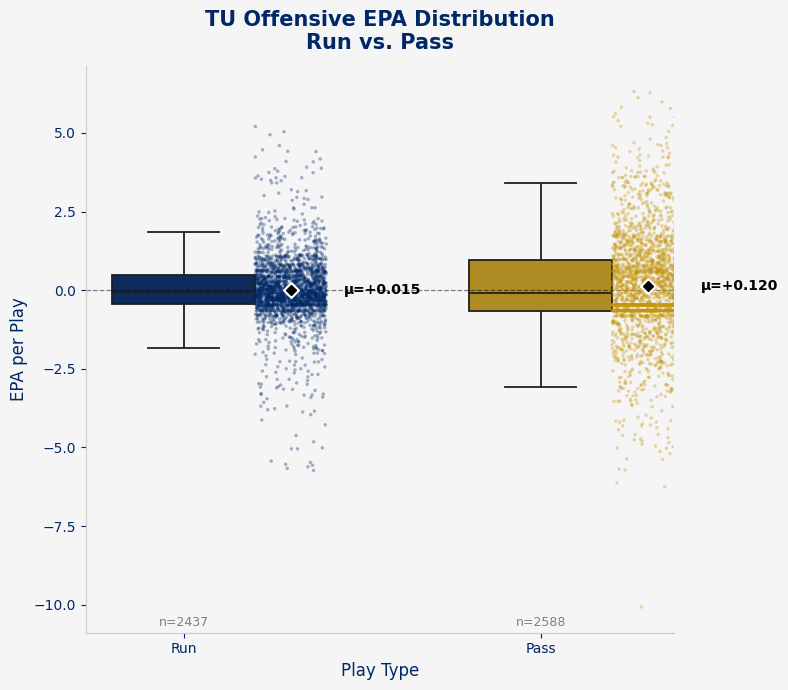

In [10]:
# Filter: run/pass offensive plays with valid EPA
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna())
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'

rp_df = off_df[off_df['play_type'].isin(['run', 'pass'])].copy()
rp_df['play_type'] = rp_df['play_type'].str.capitalize()

# Plot
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

palette = {'Run': TU_BLUE, 'Pass': TU_GOLD}

sns.boxplot(
    data=rp_df,
    x='play_type', y='epa',
    palette=palette,
    order=['Run', 'Pass'],
    width=0.4,
    linewidth=1.3,
    flierprops=dict(marker='', markersize=0),  # hide default fliers since strip covers them
    ax=ax
)

sns.stripplot(
    data=rp_df,
    x='play_type', y='epa',
    palette=palette,
    order=['Run', 'Pass'],
    size=2.5,
    alpha=0.35,
    jitter=True,
    ax=ax
)

# Nudge each strip plot group to the right of its box
OFFSET = 0.3
for i, collection in enumerate(ax.collections):
    offsets = collection.get_offsets()
    offsets[:, 0] += OFFSET
    collection.set_offsets(offsets)

# Mean markers (also nudged to sit alongside the strip)
for i, pt in enumerate(['Run', 'Pass']):
    mean_val = rp_df[rp_df['play_type'] == pt]['epa'].mean()
    count    = rp_df[rp_df['play_type'] == pt].shape[0]
    ax.plot(i + OFFSET, mean_val, marker='D', color='white', markersize=8, zorder=5)
    ax.plot(i + OFFSET, mean_val, marker='D', color='black', markersize=5, zorder=6)
    ax.text(i + OFFSET + 0.15, mean_val, f'μ={mean_val:+.3f}',
            va='center', fontsize=10, fontweight='bold', color='black')
    ax.text(i, ax.get_ylim()[0] + 0.2, f'n={count}',
            ha='center', fontsize=9, color='gray')

ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)

ax.set_title('TU Offensive EPA Distribution\nRun vs. Pass', fontsize=15, fontweight='bold', color=TU_BLUE, pad=12)
ax.set_xlabel('Play Type', fontsize=12, color=TU_BLUE)
ax.set_ylabel('EPA per Play', fontsize=12, color=TU_BLUE)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Run', 'Pass'])
ax.tick_params(colors=TU_BLUE)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig('tu_epa_run_vs_pass.png', dpi=150, bbox_inches='tight', facecolor=LIGHT_GRAY)
plt.show()
# Violin?

EPA by Field Zone Visualization

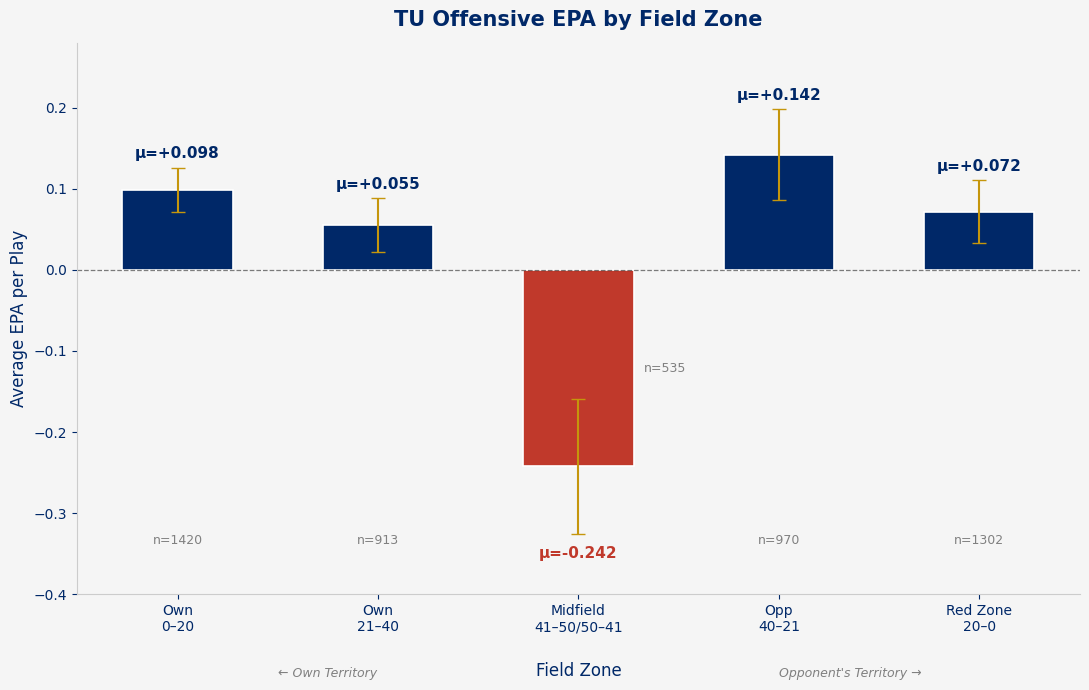

In [11]:
# Filter: TU offensive plays with valid EPA and yard_ln
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna()) &
    (tu_df['yard_ln'].notna())
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'

# Bin yard_ln into field zones
# yard_ln is negative when in own territory, positive when in opponent's
bins   = [-50, -30, -10, 10, 30, 50]
labels = ["Own\n0–20", "Own\n21–40", "Midfield\n41–50/50–41", "Opp\n40–21", "Red Zone\n20–0"]

off_df['field_zone'] = pd.cut(
    off_df['yard_ln'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Aggregate by field zone
zone_df = (
    off_df.groupby('field_zone', observed=True)['epa']
    .agg(['mean', 'sem', 'count'])
    .reset_index()
)

# Plot
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

bar_colors = [TU_BLUE if v >= 0 else '#C0392B' for v in zone_df['mean']]

bars = ax.bar(
    zone_df['field_zone'],
    zone_df['mean'],
    color=bar_colors,
    edgecolor='white',
    linewidth=1.2,
    width=0.55,
    yerr=zone_df['sem'],
    capsize=5,
    error_kw={'ecolor': TU_GOLD, 'linewidth': 1.5}
)

ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)

# Annotate bars with mean EPA and play count
for bar, row in zip(bars, zone_df.itertuples()):
    error_top    = row.mean + row.sem
    error_bottom = row.mean - row.sem

    if row.mean >= 0:
        label_y = error_top + 0.008
        va      = 'bottom'
    else:
        label_y = error_bottom - 0.015
        va      = 'top'

    ax.text(
        bar.get_x() + bar.get_width() / 2, label_y,
        f'μ={row.mean:+.3f}',
        ha='center', va=va, fontsize=11, fontweight='bold',
        color=TU_BLUE if row.mean >= 0 else '#C0392B'
    )

    # Place n= to the side for negative bars, bottom for positive
    if row.mean >= 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2, ax.get_ylim()[0] + 0.01,
            f'n={row.count}',
            ha='center', va='bottom', fontsize=9, color='gray'
        )
    else:
        ax.text(
            bar.get_x() + bar.get_width() + 0.05, row.mean / 2,
            f'n={row.count}',
            ha='left', va='center', fontsize=9, color='gray'
        )

ax.set_ylim(bottom=-0.40, top=0.28)

# Direction labels along x-axis
ax.annotate('← Own Territory', xy=(0.2, -0.15), xycoords='axes fraction',
            fontsize=9, color='gray', style='italic')
ax.annotate("Opponent's Territory →", xy=(0.7, -0.15), xycoords='axes fraction',
            fontsize=9, color='gray', style='italic')

ax.set_title('TU Offensive EPA by Field Zone', fontsize=15, fontweight='bold',
             color=TU_BLUE, pad=12)
ax.set_xlabel('Field Zone', fontsize=12, color=TU_BLUE, labelpad=20)
ax.set_ylabel('Average EPA per Play', fontsize=12, color=TU_BLUE)
ax.tick_params(colors=TU_BLUE)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig('tu_epa_by_field_zone.png', dpi=150, bbox_inches='tight', facecolor=LIGHT_GRAY)
plt.show()

Drive-level Cumulative EPA Visualization

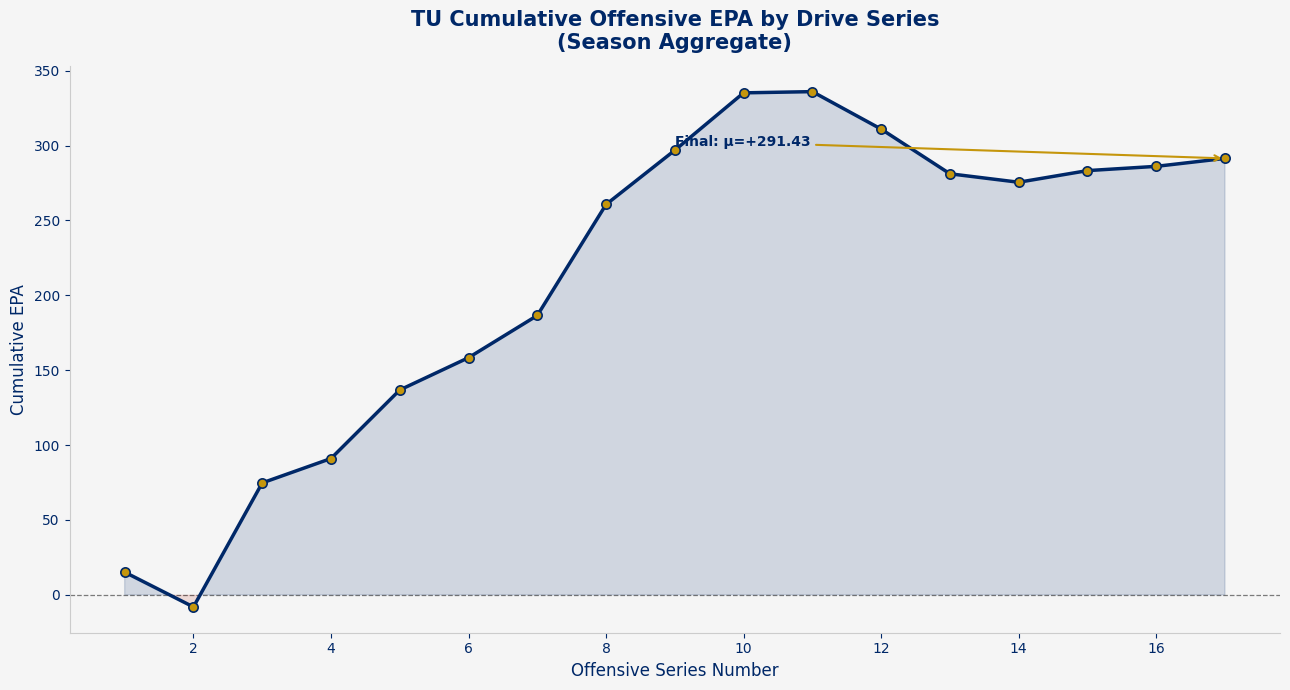

In [12]:
# Filter: TU offensive plays with valid EPA
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna())
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'

# Aggregate EPA by series across all games
series_df = (
    off_df.groupby('off_series')['epa']
    .agg(['sum', 'mean', 'count'])
    .reset_index()
    .rename(columns={'sum': 'total_epa', 'mean': 'avg_epa', 'count': 'n_plays'})
)

# Filter to series with enough plays to be meaningful
series_df = series_df[series_df['n_plays'] >= 5]

# Cumulative EPA across series
series_df['cumulative_epa'] = series_df['total_epa'].cumsum()

# Plot
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

# Shaded area under the curve
ax.fill_between(
    series_df['off_series'],
    series_df['cumulative_epa'],
    0,
    where=series_df['cumulative_epa'] >= 0,
    alpha=0.15, color=TU_BLUE, interpolate=True
)
ax.fill_between(
    series_df['off_series'],
    series_df['cumulative_epa'],
    0,
    where=series_df['cumulative_epa'] < 0,
    alpha=0.15, color='#C0392B', interpolate=True
)

# Main cumulative EPA line
ax.plot(
    series_df['off_series'],
    series_df['cumulative_epa'],
    color=TU_BLUE, linewidth=2.5, zorder=3
)

# Dot at each series
ax.scatter(
    series_df['off_series'],
    series_df['cumulative_epa'],
    color=TU_GOLD, edgecolors=TU_BLUE, linewidth=1.2,
    s=45, zorder=4
)

# Zero reference line
ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)

# Annotate final cumulative EPA
final_val = series_df['cumulative_epa'].iloc[-1]
final_ser = series_df['off_series'].iloc[-1]
ax.annotate(
    f'Final: μ={final_val:+.2f}',
    xy=(final_ser, final_val),
    xytext=(final_ser - 8, final_val + (8 if final_val >= 0 else -8)),
    fontsize=10, fontweight='bold',
    color=TU_BLUE if final_val >= 0 else '#C0392B',
    arrowprops=dict(arrowstyle='->', color=TU_GOLD, lw=1.5)
)

ax.set_title('TU Cumulative Offensive EPA by Drive Series\n(Season Aggregate)',
             fontsize=15, fontweight='bold', color=TU_BLUE, pad=12)
ax.set_xlabel('Offensive Series Number', fontsize=12, color=TU_BLUE)
ax.set_ylabel('Cumulative EPA', fontsize=12, color=TU_BLUE)
ax.tick_params(colors=TU_BLUE)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig('tu_cumulative_epa_by_series.png', dpi=150, bbox_inches='tight', facecolor=LIGHT_GRAY)
plt.show()

Cumulative EPA Per Game by Drive Visualization

In [13]:
import plotly.graph_objects as go

# Filter: TU offensive plays with valid EPA
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna())
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'

# Aggregate EPA by game and series
game_series_df = (
    off_df.groupby(['game_id', 'opp_name', 'game_date', 'team_pts', 'opp_pts', 'win', 'off_series'])['epa']
    .agg(['sum', 'count'])
    .reset_index()
    .rename(columns={'sum': 'total_epa', 'count': 'n_plays'})
)

game_series_df = game_series_df[game_series_df['n_plays'] >= 3]

game_series_df['cumulative_epa'] = (
    game_series_df.groupby('game_id')['total_epa'].cumsum()
)

# Parse dates and extract year
game_series_df['game_date_parsed'] = pd.to_datetime(
    game_series_df['game_date'], format='%m/%d/%Y'
)
game_series_df['year'] = game_series_df['game_date_parsed'].dt.year

# Build full game label
def build_label(row):
    result = 'W' if row['win'] == 1 else 'L'
    return f"{row['game_date']} vs. {row['opp_name']} ({result} {int(row['team_pts'])}-{int(row['opp_pts'])})"

game_series_df['game_label'] = game_series_df.apply(build_label, axis=1)

# Get one row per game, sorted newest → oldest
game_meta = (
    game_series_df[['game_id', 'game_label', 'game_date_parsed', 'year']]
    .drop_duplicates('game_id')
    .sort_values('game_date_parsed', ascending=False)
)

# Color palette
colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5'
]

# Build Plotly figure
fig = go.Figure()

current_year  = None
game_count    = 0
game_indices  = []
trace_index   = 0

for _, meta in game_meta.iterrows():
    game_id = meta['game_id']
    year    = meta['year']
    label   = meta['game_label']
    group   = game_series_df[game_series_df['game_id'] == game_id]
    color   = colors[game_count % len(colors)]
    game_count += 1

    # Year header
    if year != current_year:
        current_year = year
        fig.add_trace(go.Scatter(
            x=[None], y=[None],
            mode='markers',
            marker=dict(size=0, color='rgba(0,0,0,0)'),
            name=f'<b>── {year} ──</b>',
            showlegend=True,
            hoverinfo='skip',
            visible=True,
            legendgroup=f'year_{year}',   # header gets its own year group
        ))
        trace_index += 1

    hover_text = [
        f"<b>{label}</b><br>"
        f"Series: {int(row.off_series)}<br>"
        f"Series EPA: {row.total_epa:+.3f}<br>"
        f"Cumulative EPA: {row.cumulative_epa:+.3f}<br>"
        f"Plays in series: {int(row.n_plays)}"
        for row in group.itertuples()
    ]

    fig.add_trace(go.Scatter(
        x=group['off_series'],
        y=group['cumulative_epa'],
        mode='lines+markers',
        name=label,
        legendgroup=game_id,              # each game gets its OWN legendgroup
        line=dict(color=color, width=2.5),
        marker=dict(size=7, color=color, line=dict(color='white', width=1)),
        hovertemplate='%{text}<extra></extra>',
        text=hover_text,
        visible='legendonly'
    ))
    game_indices.append(trace_index)
    trace_index += 1

# Zero reference line
fig.add_hline(
    y=0, line_dash='dash',
    line_color='black', opacity=0.4, line_width=1.5
)

fig.update_layout(
    title=dict(
        text='TU Cumulative Offensive EPA by Drive Series<br>'
             '<sup>Click a game to add it — click again to remove — click a year header to toggle all games in that year</sup>',
        font=dict(size=18, color=TU_BLUE, family='Arial'),
        x=0.5, xanchor='center'
    ),
    xaxis=dict(
        title='Offensive Series Number',
        titlefont=dict(color=TU_BLUE),
        tickfont=dict(color=TU_BLUE),
        gridcolor='#DDDDDD',
        zeroline=False
    ),
    yaxis=dict(
        title='Cumulative EPA',
        titlefont=dict(color=TU_BLUE),
        tickfont=dict(color=TU_BLUE),
        gridcolor='#DDDDDD',
        zeroline=False
    ),
    legend=dict(
        title=dict(text='Game', font=dict(color=TU_BLUE, size=11)),
        bgcolor='rgba(255,255,255,0.85)',
        bordercolor='#CCCCCC',
        borderwidth=1,
        font=dict(size=10),
        itemclick='toggle',
        itemdoubleclick=False,
        tracegroupgap=2
    ),
    updatemenus=[
        dict(
            type='buttons',
            showactive=False,
            x=1.0, xanchor='right',
            y=1.08, yanchor='top',
            buttons=[
                dict(
                    label='Show All',
                    method='restyle',
                    args=[{'visible': True}, game_indices]
                ),
                dict(
                    label='Hide All',
                    method='restyle',
                    args=[{'visible': 'legendonly'}, game_indices]
                )
            ],
            bgcolor='white',
            bordercolor='#CCCCCC',
            font=dict(color=TU_BLUE, size=10)
        )
    ],
    plot_bgcolor=LIGHT_GRAY,
    paper_bgcolor=LIGHT_GRAY,
    hovermode='closest',
    height=650,
    margin=dict(t=120, b=60, l=70, r=20)
)

fig.show()
fig.write_html('tu_cumulative_epa_per_game_interactive.html')
# New one, and color by year and another color by W/L

EPA by Distance To Go Visualization

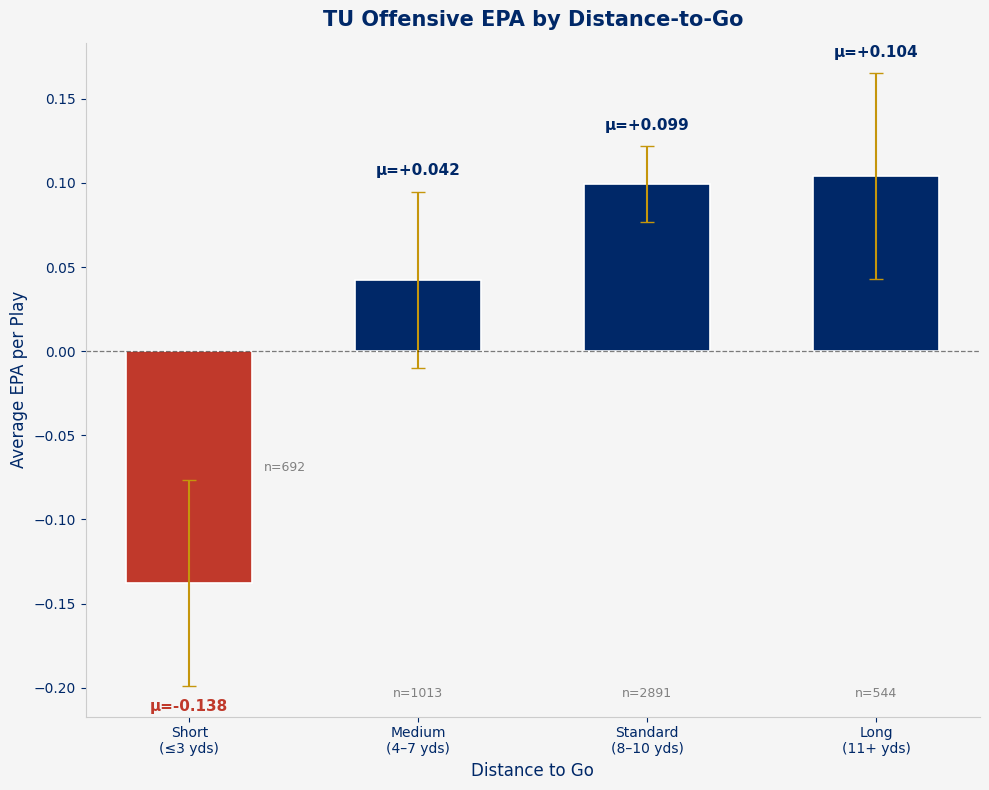

In [14]:
# Filter: TU offensive plays with valid EPA and dist
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna()) &
    (tu_df['dist'].notna())
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'

# Bin dist into distance buckets
bins   = [0, 3, 7, 10, float('inf')]
labels = ['Short\n(≤3 yds)', 'Medium\n(4–7 yds)', 'Standard\n(8–10 yds)', 'Long\n(11+ yds)']

off_df['dist_bucket'] = pd.cut(
    off_df['dist'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Aggregate by distance bucket
dist_df = (
    off_df.groupby('dist_bucket', observed=True)['epa']
    .agg(['mean', 'sem', 'count'])
    .reset_index()
)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

bar_colors = [TU_BLUE if v >= 0 else '#C0392B' for v in dist_df['mean']]

bars = ax.bar(
    dist_df['dist_bucket'],
    dist_df['mean'],
    color=bar_colors,
    edgecolor='white',
    linewidth=1.2,
    width=0.55,
    yerr=dist_df['sem'],
    capsize=5,
    error_kw={'ecolor': TU_GOLD, 'linewidth': 1.5}
)

ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)

# Annotations
for bar, row in zip(bars, dist_df.itertuples()):
    error_top    = row.mean + row.sem
    error_bottom = row.mean - row.sem

    if row.mean >= 0:
        label_y = error_top + 0.008
        va      = 'bottom'
    else:
        label_y = error_bottom - 0.008
        va      = 'top'

    ax.text(
        bar.get_x() + bar.get_width() / 2, label_y,
        f'μ={row.mean:+.3f}',
        ha='center', va=va, fontsize=11, fontweight='bold',
        color=TU_BLUE if row.mean >= 0 else '#C0392B'
    )

    if row.mean >= 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2, ax.get_ylim()[0] + 0.01,
            f'n={row.count}',
            ha='center', va='bottom', fontsize=9, color='gray'
        )
    else:
        ax.text(
            bar.get_x() + bar.get_width() + 0.05, row.mean / 2,
            f'n={row.count}',
            ha='left', va='center', fontsize=9, color='gray'
        )

ax.set_title('TU Offensive EPA by Distance-to-Go',
             fontsize=15, fontweight='bold', color=TU_BLUE, pad=12)
ax.set_xlabel('Distance to Go', fontsize=12, color=TU_BLUE)
ax.set_ylabel('Average EPA per Play', fontsize=12, color=TU_BLUE)
ax.tick_params(colors=TU_BLUE)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig('tu_epa_by_distance.png', dpi=150, bbox_inches='tight', facecolor=LIGHT_GRAY)
plt.show()

EPA Distribution by Result Types Visualizations

/tmp/ipykernel_48580/3670146313.py:53: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




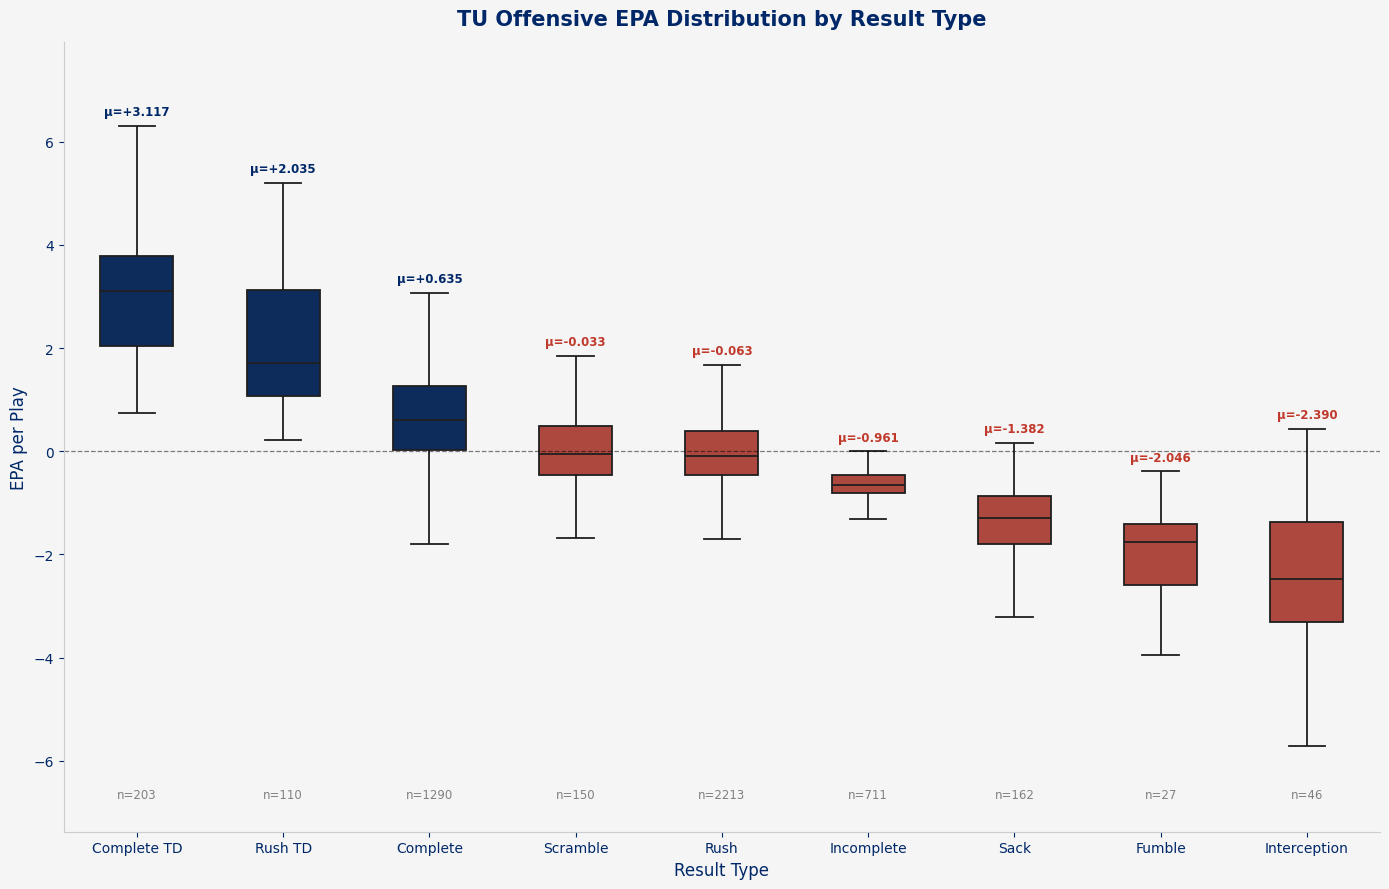

In [15]:
# Filter: TU offensive plays with valid EPA and result
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna()) &
    (tu_df['result'].notna())
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'

# Clean and filter result types
off_df['result'] = off_df['result'].str.strip().str.lower()

keep_results = ['rush', 'complete', 'incomplete', 'interception',
                'sack', 'scramble', 'complete, td', 'rush, td', 'fumble']

off_df = off_df[off_df['result'].isin(keep_results)].copy()

label_map = {
    'rush'        : 'Rush',
    'complete'    : 'Complete',
    'incomplete'  : 'Incomplete',
    'interception': 'Interception',
    'sack'        : 'Sack',
    'scramble'    : 'Scramble',
    'complete, td': 'Complete TD',
    'rush, td'    : 'Rush TD',
    'fumble'      : 'Fumble'
}
off_df['result_label'] = off_df['result'].map(label_map)

# Order by median EPA descending
result_order = (
    off_df.groupby('result_label')['epa']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# Color — positive median = TU Blue, negative = red
median_vals = off_df.groupby('result_label')['epa'].median()
box_colors  = [
    TU_BLUE if median_vals[r] >= 0 else '#C0392B'
    for r in result_order
]

# Plot
fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

sns.boxplot(
    data=off_df,
    x='result_label', y='epa',
    order=result_order,
    palette={r: c for r, c in zip(result_order, box_colors)},
    width=0.5,
    linewidth=1.3,
    flierprops=dict(
        marker='o', markersize=3,
        alpha=0.3, linestyle='none',
        markeredgewidth=0
    ),
    ax=ax
)

# Compute whisker tops and place mean labels above them
for i, result in enumerate(result_order):
    subset   = off_df[off_df['result_label'] == result]['epa']
    mean_val = subset.mean()
    count    = subset.count()
    Q3       = subset.quantile(0.75)
    IQR      = subset.quantile(0.75) - subset.quantile(0.25)
    whisker_top = subset[subset <= Q3 + 1.5 * IQR].max()

    # Mean label just above the top whisker
    ax.text(
        i, whisker_top + 0.15,
        f'μ={mean_val:+.3f}',
        ha='center', va='bottom',
        fontsize=8.5, fontweight='bold',
        color=TU_BLUE if median_vals[result] >= 0 else '#C0392B'
    )

    # n= always at the bottom
    ax.text(
        i, ax.get_ylim()[0] + 0.1, f'n={count}',
        ha='center', va='bottom', fontsize=8.5, color='gray'
    )

ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)

ax.set_title('TU Offensive EPA Distribution by Result Type',
             fontsize=15, fontweight='bold', color=TU_BLUE, pad=12)
ax.set_xlabel('Result Type', fontsize=12, color=TU_BLUE)
ax.set_ylabel('EPA per Play', fontsize=12, color=TU_BLUE)
ax.set_ylim(bottom=ax.get_ylim()[0] - 0.5, top=ax.get_ylim()[1] + 1.0)
ax.tick_params(colors=TU_BLUE)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig('tu_epa_by_result_type.png', dpi=150, bbox_inches='tight', facecolor=LIGHT_GRAY)
plt.show()

EPA by Personnel Visualization

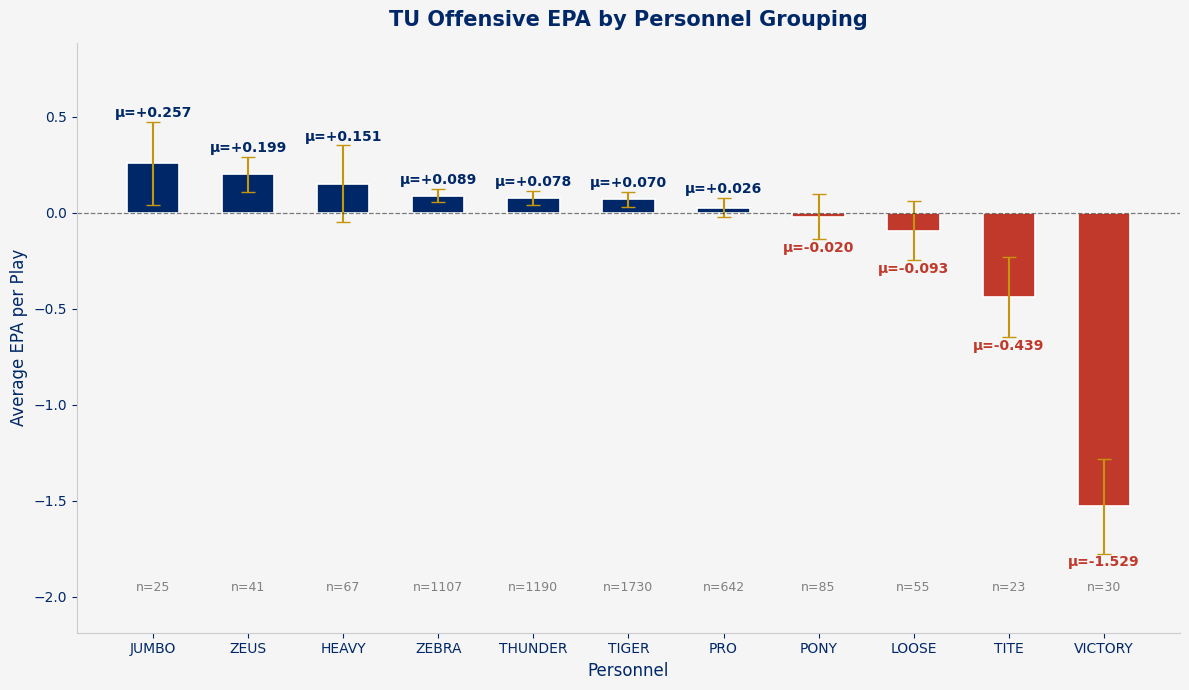

In [16]:
# Filter: TU offensive plays with valid EPA and personnel
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna()) &
    (tu_df['personnel'].notna())
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'

# Aggregate by personnel
pers_df = (
    off_df.groupby('personnel')['epa']
    .agg(['mean', 'sem', 'count'])
    .reset_index()
)

pers_df = pers_df[pers_df['count'] >= 20].sort_values('mean', ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

bar_colors = [TU_BLUE if v >= 0 else '#C0392B' for v in pers_df['mean']]

bars = ax.bar(
    pers_df['personnel'],
    pers_df['mean'],
    color=bar_colors,
    edgecolor='white',
    linewidth=1.2,
    width=0.55,
    yerr=pers_df['sem'],
    capsize=5,
    error_kw={'ecolor': TU_GOLD, 'linewidth': 1.5}
)

ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)

for bar, row in zip(bars, pers_df.itertuples()):
    error_top    = row.mean + row.sem
    error_bottom = row.mean - row.sem

    if row.mean >= 0:
        label_y = error_top + 0.008
        va      = 'bottom'
    else:
        label_y = error_bottom - 0.008
        va      = 'top'

    ax.text(
        bar.get_x() + bar.get_width() / 2, label_y,
        f'μ={row.mean:+.3f}',
        ha='center', va=va, fontsize=10, fontweight='bold',
        color=TU_BLUE if row.mean >= 0 else '#C0392B'
    )

    # n= always at the bottom for all bars
    ax.text(
        bar.get_x() + bar.get_width() / 2, ax.get_ylim()[0] - 0.1,
        f'n={row.count}',
        ha='center', va='bottom', fontsize=9, color='gray'
    )

ax.set_title('TU Offensive EPA by Personnel Grouping',
             fontsize=15, fontweight='bold', color=TU_BLUE, pad=12)
ax.set_xlabel('Personnel', fontsize=12, color=TU_BLUE)
ax.set_ylabel('Average EPA per Play', fontsize=12, color=TU_BLUE)
ax.set_ylim(bottom=ax.get_ylim()[0] - 0.3, top=ax.get_ylim()[1] + 0.3)
ax.tick_params(colors=TU_BLUE)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig('tu_epa_by_personnel.png', dpi=150, bbox_inches='tight', facecolor=LIGHT_GRAY)
plt.show()

In [17]:
# EPA by Formation

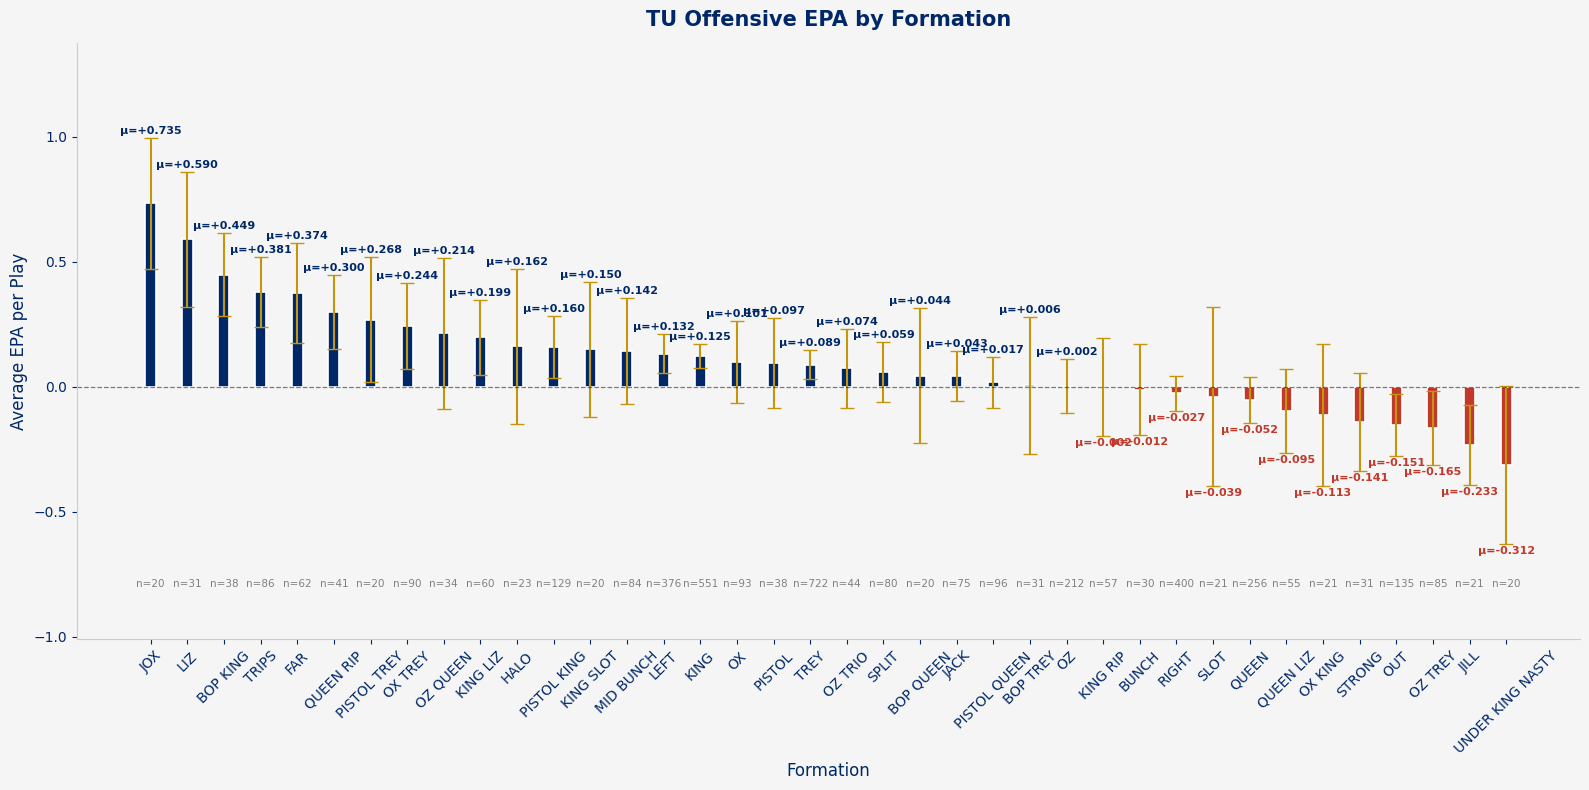

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import re

# ── Filter: TU offensive plays with valid EPA and off_form ────────────────────
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna()) &
    (tu_df['off_form'].notna())
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'

# ── Normalize formation — collapse RIGHT/LEFT variants ────────────────────────
def normalize_formation(form):
    form = str(form).strip().upper()
    # If the formation is ONLY the word RIGHT or LEFT, keep it as-is
    if form in ['RIGHT', 'LEFT']:
        return form
    # Otherwise strip trailing or leading RIGHT/LEFT to get the base name
    form = re.sub(r'\bRIGHT\b', '', form)
    form = re.sub(r'\bLEFT\b', '', form)
    form = ' '.join(form.split())   # clean up extra whitespace
    return form if form else 'OTHER'

off_df['form_normalized'] = off_df['off_form'].apply(normalize_formation)

# ── Aggregate by normalized formation ────────────────────────────────────────
form_df = (
    off_df.groupby('form_normalized')['epa']
    .agg(['mean', 'sem', 'count'])
    .reset_index()
)

form_df = form_df[form_df['count'] >= 20].sort_values('mean', ascending=False)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

bar_colors = [TU_BLUE if v >= 0 else '#C0392B' for v in form_df['mean']]

bars = ax.bar(
    form_df['form_normalized'],
    form_df['mean'],
    color=bar_colors,
    edgecolor='white',
    linewidth=1.2,
    width=0.3,
    yerr=form_df['sem'],
    capsize=5,
    error_kw={'ecolor': TU_GOLD, 'linewidth': 1.5}
)

ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)

for bar, row in zip(bars, form_df.itertuples()):
    error_top    = row.mean + row.sem
    error_bottom = row.mean - row.sem

    if row.mean >= 0:
        label_y = error_top + 0.008
        va      = 'bottom'
    else:
        label_y = error_bottom - 0.008
        va      = 'top'

    ax.text(
        bar.get_x() + bar.get_width() / 2, label_y,
        f'μ={row.mean:+.3f}',
        ha='center', va=va, fontsize=8, fontweight='bold',
        color=TU_BLUE if row.mean >= 0 else '#C0392B'
    )

    # n= always at the bottom for all bars
    ax.text(
        bar.get_x() + bar.get_width() / 2, ax.get_ylim()[0] - 0.1,
        f'n={row.count}',
        ha='center', va='bottom', fontsize=7.5, color='gray'
    )

ax.set_title('TU Offensive EPA by Formation',
             fontsize=15, fontweight='bold', color=TU_BLUE, pad=12)
ax.set_xlabel('Formation', fontsize=12, color=TU_BLUE)
ax.set_ylabel('Average EPA per Play', fontsize=12, color=TU_BLUE)
ax.set_ylim(bottom=ax.get_ylim()[0] - 0.3, top=ax.get_ylim()[1] + 0.3)
ax.tick_params(axis='x', colors=TU_BLUE, rotation=45)
ax.tick_params(axis='y', colors=TU_BLUE)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig('tu_epa_by_formation.png', dpi=150, bbox_inches='tight', facecolor=LIGHT_GRAY)
plt.show()

EPA by Personnel and Formation Visualization

In [19]:
# Filter
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna()) &
    (tu_df['personnel'].notna()) &
    (tu_df['off_form'].notna())
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'

# Normalize formation
def normalize_formation(form):
    form = str(form).strip().upper()
    if form in ['RIGHT', 'LEFT']:
        return form
    form = re.sub(r'\bRIGHT\b', '', form)
    form = re.sub(r'\bLEFT\b', '', form)
    form = ' '.join(form.split())
    return form if form else 'OTHER'

off_df['form_normalized'] = off_df['off_form'].apply(normalize_formation)

# Aggregate by personnel + formation combination
combo_df = (
    off_df.groupby(['personnel', 'form_normalized'])['epa']
    .agg(['mean', 'sem', 'count'])
    .reset_index()
    .rename(columns={'form_normalized': 'formation'})
)

combo_df = combo_df[combo_df['count'] >= 10].copy()

# Sort personnel by avg EPA
personnel_list = (
    combo_df.groupby('personnel')['mean']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

# Color palette for personnel
pers_colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'
]
pers_color_map = {p: pers_colors[i % len(pers_colors)]
                  for i, p in enumerate(personnel_list)}

# Build figure — ONE trace per personnel
# Each trace only contains formations that exist for that personnel
# sorted by mean EPA so best formations appear first on the x axis
fig = go.Figure()

for pers in personnel_list:
    pers_data = (
        combo_df[combo_df['personnel'] == pers]
        .sort_values('mean', ascending=False)
        .reset_index(drop=True)
    )
    color = pers_color_map[pers]

    hover_text = [
        f"<b>{pers} | {row['formation']}</b><br>"
        f"μ EPA: {row['mean']:+.3f}<br>"
        f"Std Err: ±{row['sem']:.3f}<br>"
        f"n={int(row['count'])}"
        for _, row in pers_data.iterrows()
    ]

    fig.add_trace(go.Bar(
        x=pers_data['formation'],
        y=pers_data['mean'],
        error_y=dict(
            type='data',
            array=pers_data['sem'].tolist(),
            color=TU_GOLD, thickness=1.5, width=4
        ),
        name=pers,
        marker_color=[TU_BLUE if v >= 0 else '#C0392B'
                      for v in pers_data['mean']],
        marker_line_color='white',
        marker_line_width=1.2,
        text=hover_text,
        hovertemplate='%{text}<extra></extra>',
        visible='legendonly',
        legendgroup=pers,
        showlegend=True
    ))

# Zero reference line
fig.add_hline(y=0, line_dash='dash', line_color='black',
              opacity=0.4, line_width=1.5)

n_traces = len(fig.data)

# Layout
fig.update_layout(
    title=dict(
        text='TU Offensive EPA by Personnel & Formation<br>'
             '<sup>Click a personnel group to show its formations — click again to remove</sup>',
        font=dict(size=17, color=TU_BLUE, family='Arial'),
        x=0.5, xanchor='center'
    ),
    xaxis=dict(
        title='Formation',
        titlefont=dict(color=TU_BLUE),
        tickfont=dict(color=TU_BLUE),
        tickangle=45,
        gridcolor='#DDDDDD',
        zeroline=False,
        # Dynamic — only shows formations for visible traces
        autorange=True
    ),
    yaxis=dict(
        title='Average EPA per Play',
        titlefont=dict(color=TU_BLUE),
        tickfont=dict(color=TU_BLUE),
        gridcolor='#DDDDDD',
        zeroline=False
    ),
    barmode='group',
    legend=dict(
        title=dict(text='Personnel', font=dict(color=TU_BLUE, size=11)),
        bgcolor='rgba(255,255,255,0.85)',
        bordercolor='#CCCCCC',
        borderwidth=1,
        font=dict(size=10),
        itemclick='toggle',
        itemdoubleclick=False,
    ),
    updatemenus=[
        dict(
            type='buttons',
            showactive=False,
            x=1.0, xanchor='right',
            y=1.08, yanchor='top',
            buttons=[
                dict(
                    label='Show All',
                    method='restyle',
                    args=[{'visible': True}, list(range(n_traces))]
                ),
                dict(
                    label='Hide All',
                    method='restyle',
                    args=[{'visible': 'legendonly'}, list(range(n_traces))]
                )
            ],
            bgcolor='white',
            bordercolor='#CCCCCC',
            font=dict(color=TU_BLUE, size=10)
        )
    ],
    plot_bgcolor=LIGHT_GRAY,
    paper_bgcolor=LIGHT_GRAY,
    hovermode='closest',
    height=650,
    margin=dict(t=120, b=160, l=70, r=20)
)

fig.show()
fig.write_html('tu_epa_personnel_formation_combo_interactive.html')

Explosive Play EPA vs. Non-explosive Visualization

/tmp/ipykernel_48580/1119518743.py:47: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




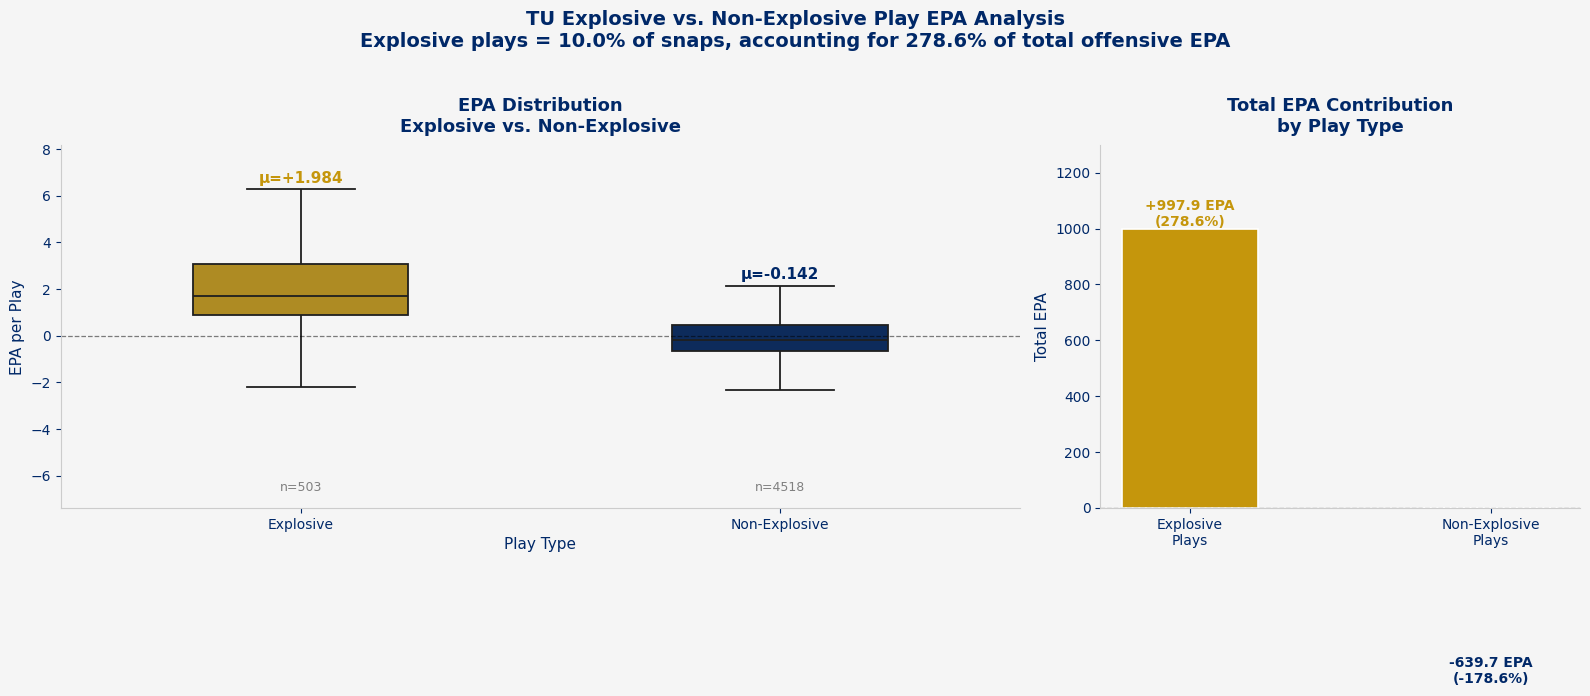

In [20]:
# Filter: TU offensive plays with valid EPA and gn_ls
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna()) &
    (tu_df['gn_ls'].notna()) &
    (tu_df['play_type'].isin(['run', 'pass']))
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'

# Flag explosive plays
# Run ≥ 12 yards or Pass ≥ 21 yards
off_df['explosive'] = (
    ((off_df['play_type'] == 'run')  & (off_df['gn_ls'] >= 12)) |
    ((off_df['play_type'] == 'pass') & (off_df['gn_ls'] >= 21))
)
off_df['explosive_label'] = off_df['explosive'].map(
    {True: 'Explosive', False: 'Non-Explosive'}
)

# Summary stats
summary = (
    off_df.groupby('explosive_label')['epa']
    .agg(['mean', 'median', 'std', 'count'])
    .reset_index()
)

total_epa        = off_df['epa'].sum()
explosive_epa    = off_df[off_df['explosive']]['epa'].sum()
explosive_pct    = (explosive_epa / total_epa * 100) if total_epa != 0 else 0
explosive_play_pct = (off_df['explosive'].sum() / len(off_df) * 100)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 8),
                         gridspec_kw={'width_ratios': [2, 1]})
fig.patch.set_facecolor(LIGHT_GRAY)

order   = ['Explosive', 'Non-Explosive']
palette = {'Explosive': TU_GOLD, 'Non-Explosive': TU_BLUE}

# Left — Box plot
ax1 = axes[0]
ax1.set_facecolor(LIGHT_GRAY)

sns.boxplot(
    data=off_df,
    x='explosive_label', y='epa',
    order=order,
    palette=palette,
    width=0.45,
    linewidth=1.3,
    flierprops=dict(marker='o', markersize=3, alpha=0.3,
                    linestyle='none', markeredgewidth=0),
    ax=ax1
)

# Mean labels above top whisker
for i, label in enumerate(order):
    subset      = off_df[off_df['explosive_label'] == label]['epa']
    mean_val    = subset.mean()
    count       = subset.count()
    Q3          = subset.quantile(0.75)
    IQR         = Q3 - subset.quantile(0.25)
    whisker_top = subset[subset <= Q3 + 1.5 * IQR].max()

    ax1.text(
        i, whisker_top + 0.15,
        f'μ={mean_val:+.3f}',
        ha='center', va='bottom', fontsize=11,
        fontweight='bold',
        color=TU_GOLD if label == 'Explosive' else TU_BLUE
    )
    ax1.text(
        i, ax1.get_ylim()[0] + 0.1,
        f'n={count}',
        ha='center', va='bottom', fontsize=9, color='gray'
    )

ax1.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax1.set_title('EPA Distribution\nExplosive vs. Non-Explosive',
              fontsize=13, fontweight='bold', color=TU_BLUE, pad=10)
ax1.set_xlabel('Play Type', fontsize=11, color=TU_BLUE)
ax1.set_ylabel('EPA per Play', fontsize=11, color=TU_BLUE)
ax1.set_ylim(bottom=ax1.get_ylim()[0] - 0.5, top=ax1.get_ylim()[1] + 1.2)
ax1.tick_params(colors=TU_BLUE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color('#CCCCCC')

# Right — EPA contribution bar chart
ax2 = axes[1]
ax2.set_facecolor(LIGHT_GRAY)

contrib_labels = ['Explosive\nPlays', 'Non-Explosive\nPlays']
contrib_values = [explosive_epa, total_epa - explosive_epa]
contrib_colors = [TU_GOLD, TU_BLUE]

bars = ax2.bar(
    contrib_labels,
    contrib_values,
    color=contrib_colors,
    edgecolor='white',
    linewidth=1.2,
    width=0.45
)

for bar, val in zip(bars, contrib_values):
    pct = val / total_epa * 100
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f'{val:+.1f} EPA\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=10,
        fontweight='bold',
        color=TU_GOLD if val == explosive_epa else TU_BLUE
    )

ax2.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax2.set_title('Total EPA Contribution\nby Play Type',
              fontsize=13, fontweight='bold', color=TU_BLUE, pad=10)
ax2.set_ylabel('Total EPA', fontsize=11, color=TU_BLUE)
ax2.set_ylim(bottom=0, top=max(contrib_values) * 1.3)
ax2.tick_params(colors=TU_BLUE)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color('#CCCCCC')

# Super title with key context stats
fig.suptitle(
    f'TU Explosive vs. Non-Explosive Play EPA Analysis\n'
    f'Explosive plays = {explosive_play_pct:.1f}% of snaps, '
    f'accounting for {explosive_pct:.1f}% of total offensive EPA',
    fontsize=14, fontweight='bold', color=TU_BLUE, y=1.02
)

plt.tight_layout()
plt.savefig('tu_epa_explosive_vs_nonexplosive.png', dpi=150,
            bbox_inches='tight', facecolor=LIGHT_GRAY)
plt.show()

EPA on 3rd Down by Distance Visualization

/tmp/ipykernel_48580/822146440.py:61: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




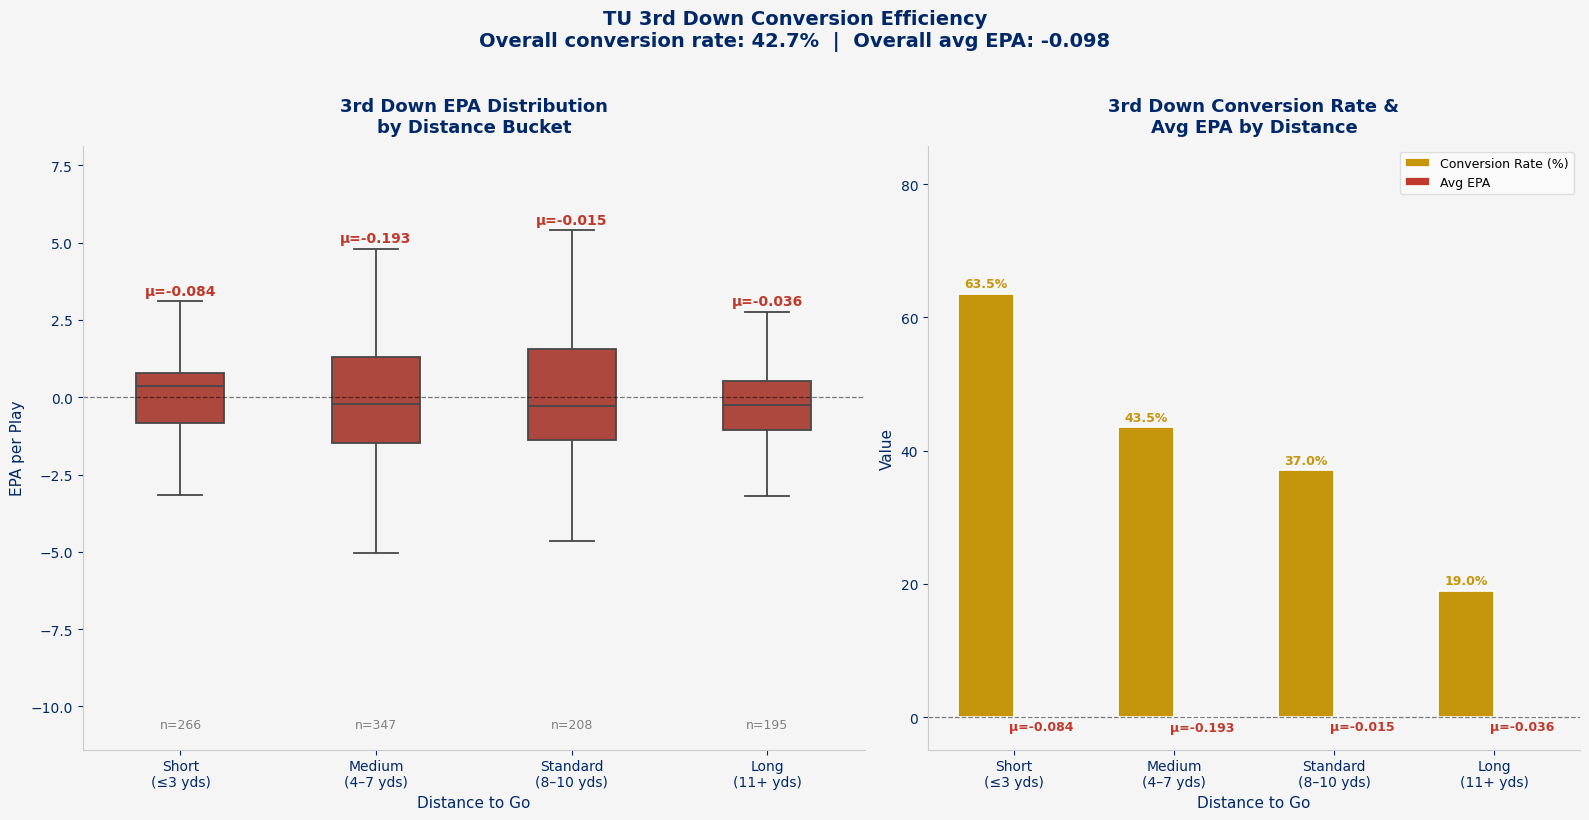

In [21]:
# Filter: TU 3rd down offensive plays with valid EPA
third_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna()) &
    (tu_df['dist'].notna()) &
    (tu_df['dn'] == 3)
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
LIGHT_GRAY = '#F5F5F5'

# Bin dist into distance buckets
bins   = [0, 3, 7, 10, float('inf')]
labels = ['Short\n(≤3 yds)', 'Medium\n(4–7 yds)',
          'Standard\n(8–10 yds)', 'Long\n(11+ yds)']

third_df['dist_bucket'] = pd.cut(
    third_df['dist'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Flag conversion
convert_results = ['complete', 'rush', 'scramble', 'complete, td',
                   'rush, td', 'complete, td']
third_df['converted'] = third_df['result'].str.strip().str.lower().isin(
    convert_results
) & (third_df['gn_ls'] >= third_df['dist'])

# Aggregate by distance bucket
bucket_df = (
    third_df.groupby('dist_bucket', observed=True)
    .agg(
        mean_epa    =('epa', 'mean'),
        sem_epa     =('epa', 'sem'),
        count       =('epa', 'count'),
        conv_rate   =('converted', 'mean')
    )
    .reset_index()
)

# Plot: two panels
fig, axes = plt.subplots(1, 2, figsize=(16, 8),
                         gridspec_kw={'width_ratios': [1.2, 1]})
fig.patch.set_facecolor(LIGHT_GRAY)

# Left — Box plot of EPA by distance bucket
ax1 = axes[0]
ax1.set_facecolor(LIGHT_GRAY)

bucket_order  = labels
bucket_colors = {
    b: (TU_BLUE if bucket_df.loc[
        bucket_df['dist_bucket'] == b, 'mean_epa'].values[0] >= 0
        else '#C0392B')
    for b in bucket_order
}

sns.boxplot(
    data=third_df,
    x='dist_bucket', y='epa',
    order=bucket_order,
    palette=bucket_colors,
    width=0.45,
    linewidth=1.3,
    flierprops=dict(marker='o', markersize=3, alpha=0.3,
                    linestyle='none', markeredgewidth=0),
    ax=ax1
)

for i, bucket in enumerate(bucket_order):
    subset      = third_df[third_df['dist_bucket'] == bucket]['epa']
    if len(subset) == 0:
        continue
    mean_val    = subset.mean()
    count       = subset.count()
    Q3          = subset.quantile(0.75)
    IQR         = Q3 - subset.quantile(0.25)
    whisker_top = subset[subset <= Q3 + 1.5 * IQR].max()

    ax1.text(
        i, whisker_top + 0.12,
        f'μ={mean_val:+.3f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold',
        color=TU_BLUE if mean_val >= 0 else '#C0392B'
    )
    ax1.text(
        i, ax1.get_ylim()[0] + 0.1,
        f'n={count}',
        ha='center', va='bottom', fontsize=9, color='gray'
    )

ax1.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax1.set_title('3rd Down EPA Distribution\nby Distance Bucket',
              fontsize=13, fontweight='bold', color=TU_BLUE, pad=10)
ax1.set_xlabel('Distance to Go', fontsize=11, color=TU_BLUE)
ax1.set_ylabel('EPA per Play', fontsize=11, color=TU_BLUE)
ax1.set_ylim(bottom=ax1.get_ylim()[0] - 0.5,
             top=ax1.get_ylim()[1] + 1.0)
ax1.tick_params(colors=TU_BLUE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color('#CCCCCC')

# Right — Conversion rate + avg EPA bar chart
ax2 = axes[1]
ax2.set_facecolor(LIGHT_GRAY)

x      = range(len(bucket_df))
width  = 0.35
colors = [TU_BLUE if v >= 0 else '#C0392B' for v in bucket_df['mean_epa']]

# Conversion rate bars (left of each pair)
bars1 = ax2.bar(
    [i - width / 2 for i in x],
    bucket_df['conv_rate'] * 100,
    width=width,
    color=TU_GOLD,
    edgecolor='white',
    linewidth=1.2,
    label='Conversion Rate (%)'
)

# Mean EPA bars (right of each pair)
bars2 = ax2.bar(
    [i + width / 2 for i in x],
    bucket_df['mean_epa'],
    width=width,
    color=colors,
    edgecolor='white',
    linewidth=1.2,
    label='Avg EPA'
)

# Annotate conversion rate bars
for bar, row in zip(bars1, bucket_df.itertuples()):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{row.conv_rate * 100:.1f}%',
        ha='center', va='bottom', fontsize=9,
        fontweight='bold', color=TU_GOLD
    )

# Annotate EPA bars
for bar, row in zip(bars2, bucket_df.itertuples()):
    error_top    = row.mean_epa + row.sem_epa
    error_bottom = row.mean_epa - row.sem_epa
    if row.mean_epa >= 0:
        label_y = error_top + 0.3
        va      = 'bottom'
    else:
        label_y = error_bottom - 0.3
        va      = 'top'
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        label_y,
        f'μ={row.mean_epa:+.3f}',
        ha='center', va=va, fontsize=9,
        fontweight='bold',
        color=TU_BLUE if row.mean_epa >= 0 else '#C0392B'
    )

ax2.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax2.set_xticks(list(x))
ax2.set_xticklabels(bucket_df['dist_bucket'], color=TU_BLUE)
ax2.set_title('3rd Down Conversion Rate &\nAvg EPA by Distance',
              fontsize=13, fontweight='bold', color=TU_BLUE, pad=10)
ax2.set_xlabel('Distance to Go', fontsize=11, color=TU_BLUE)
ax2.set_ylabel('Value', fontsize=11, color=TU_BLUE)
ax2.set_ylim(bottom=ax2.get_ylim()[0] - 1.5,
             top=max(bucket_df['conv_rate'] * 100) * 1.35)
ax2.tick_params(colors=TU_BLUE)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color('#CCCCCC')
ax2.legend(fontsize=9, framealpha=0.6, edgecolor='#CCCCCC')

# Super title
overall_conv  = third_df['converted'].mean() * 100
overall_epa   = third_df['epa'].mean()
fig.suptitle(
    f'TU 3rd Down Conversion Efficiency\n'
    f'Overall conversion rate: {overall_conv:.1f}%  |  '
    f'Overall avg EPA: {overall_epa:+.3f}',
    fontsize=14, fontweight='bold', color=TU_BLUE, y=1.02
)

plt.tight_layout()
plt.savefig('tu_epa_3rd_down_conversion.png', dpi=150,
            bbox_inches='tight', facecolor=LIGHT_GRAY)
plt.show()

EPA Win/Loss Fingerprint Visualization

In [22]:
# Filter: TU offensive plays with valid EPA
off_df = tu_df[
    (tu_df['odk'] == 'o') &
    (tu_df['epa'].notna())
].copy()

TU_BLUE    = '#002868'
TU_GOLD    = '#C5960C'
WIN_COLOR  = '#2ca02c'
LOSS_COLOR = '#C0392B'
LIGHT_GRAY = '#F5F5F5'

# Parse year
off_df['game_date_parsed'] = pd.to_datetime(
    off_df['game_date'], format='%m/%d/%Y'
)
off_df['year'] = off_df['game_date_parsed'].dt.year
years          = sorted(off_df['year'].unique(), reverse=True)

# Helper: safe mean
def safe_mean(series):
    return series.mean() if len(series) > 0 else 0

# Compute metrics split by win/loss for a given dataframe
def build_metrics(df):
    run_df  = df[df['play_type'] == 'run']
    pass_df = df[df['play_type'] == 'pass']
    dn1_df  = df[df['dn'] == 1]
    dn2_df  = df[df['dn'] == 2]
    dn3_df  = df[(df['dn'] == 3) & (df['dist'].notna())].copy()
    rz_df   = df[df['yard_ln'] >= 20]

    if len(dn3_df) > 0:
        convert_results = ['complete', 'rush', 'scramble',
                           'complete, td', 'rush, td']
        dn3_df['converted'] = (
            dn3_df['result'].str.strip().str.lower().isin(convert_results) &
            (dn3_df['gn_ls'] >= dn3_df['dist'])
        )
        conv_rate = dn3_df['converted'].mean()
    else:
        conv_rate = 0

    if df['gn_ls'].notna().any():
        exp_df  = df[
            ((df['play_type'] == 'run')  & (df['gn_ls'] >= 12)) |
            ((df['play_type'] == 'pass') & (df['gn_ls'] >= 21))
        ]
        exp_epa = safe_mean(exp_df['epa'])
    else:
        exp_epa = 0

    return {
        '1st Down EPA'       : safe_mean(dn1_df['epa']),
        '2nd Down EPA'       : safe_mean(dn2_df['epa']),
        '3rd Down EPA'       : safe_mean(dn3_df['epa']),
        'Run EPA'            : safe_mean(run_df['epa']),
        'Pass EPA'           : safe_mean(pass_df['epa']),
        'Red Zone EPA'       : safe_mean(rz_df['epa']),
        'Explosive EPA'      : exp_epa,
        '3rd Down Conv Rate' : conv_rate,
    }

# Normalize metrics to 0-1 across wins + losses
def normalize_metrics(win_metrics, loss_metrics):
    categories = list(win_metrics.keys())
    norm_wins, norm_losses = [], []

    for cat in categories:
        vals = [win_metrics[cat], loss_metrics[cat]]
        vmin = min(vals) - abs(min(vals)) * 0.2
        vmax = max(vals) + abs(max(vals)) * 0.2
        rng  = vmax - vmin if vmax != vmin else 1
        norm_wins.append((win_metrics[cat] - vmin) / rng)
        norm_losses.append((loss_metrics[cat] - vmin) / rng)

    return norm_wins, norm_losses

# Build traces for a given year filter
def build_traces(df):
    categories = ['1st Down EPA', '2nd Down EPA', '3rd Down EPA',
                  'Run EPA', 'Pass EPA', 'Red Zone EPA',
                  'Explosive EPA', '3rd Down Conv Rate']

    wins_df   = df[df['win'] == 1]
    losses_df = df[df['win'] == 0]

    win_metrics  = build_metrics(wins_df)
    loss_metrics = build_metrics(losses_df)

    norm_wins, norm_losses = normalize_metrics(win_metrics, loss_metrics)

    raw_wins   = [win_metrics[c]  for c in categories]
    raw_losses = [loss_metrics[c] for c in categories]

    # Close polygons
    cats_closed   = categories + [categories[0]]
    nw_closed     = norm_wins   + [norm_wins[0]]
    nl_closed     = norm_losses + [norm_losses[0]]
    rw_closed     = raw_wins    + [raw_wins[0]]
    rl_closed     = raw_losses  + [raw_losses[0]]

    # Win/loss record
    game_records = (
        df.groupby(['game_id', 'win'])
        .size().reset_index()[['game_id', 'win']]
        .drop_duplicates('game_id')
    )
    n_wins   = (game_records['win'] == 1).sum()
    n_losses = (game_records['win'] == 0).sum()

    # Biggest divergence
    divergence   = [abs(w - l) for w, l in zip(raw_wins, raw_losses)]
    max_div_cat  = categories[divergence.index(max(divergence))]

    return nw_closed, nl_closed, rw_closed, rl_closed, cats_closed, \
           n_wins, n_losses, max_div_cat

# Build figure with all years as frame sets
fig = go.Figure()

# We build one set of traces per year option + one for all years
year_options = ['All Years'] + [str(y) for y in years]

all_traces      = []   # list of (win_trace, loss_trace) per year option
all_titles      = []

for option in year_options:
    if option == 'All Years':
        subset = off_df.copy()
    else:
        subset = off_df[off_df['year'] == int(option)].copy()

    nw, nl, rw, rl, cats, n_wins, n_losses, max_div = build_traces(subset)

    all_traces.append((nw, nl, rw, rl, cats))
    all_titles.append(
        f'TU Offensive EPA Win/Loss Fingerprint — {option}<br>'
        f'<sup>Record: {n_wins}W – {n_losses}L  |  '
        f'Biggest divergence: <b>{max_div}</b>  |  '
        f'Hover for raw values</sup>'
    )

# Add initial traces (All Years)
nw, nl, rw, rl, cats = all_traces[0]
n_wins_all   = sum(1 for _ in off_df.groupby('game_id') if _[1]['win'].iloc[0] == 1)

fig.add_trace(go.Scatterpolar(
    r=nw, theta=cats, fill='toself',
    fillcolor='rgba(44, 160, 44, 0.15)',
    line=dict(color=WIN_COLOR, width=2.5),
    name='Wins',
    customdata=list(zip(rw, cats)),
    hovertemplate='<b>%{customdata[1]}</b><br>Value: %{customdata[0]:.3f}<extra></extra>'
))

fig.add_trace(go.Scatterpolar(
    r=nl, theta=cats, fill='toself',
    fillcolor='rgba(192, 57, 43, 0.15)',
    line=dict(color=LOSS_COLOR, width=2.5),
    name='Losses',
    customdata=list(zip(rl, cats)),
    hovertemplate='<b>%{customdata[1]}</b><br>Value: %{customdata[0]:.3f}<extra></extra>'
))

# Build dropdown buttons
buttons = []
for i, option in enumerate(year_options):
    nw, nl, rw, rl, cats = all_traces[i]
    buttons.append(dict(
        label=option,
        method='update',
        args=[
            {   # update trace data
                'r'          : [nw, nl],
                'theta'      : [cats, cats],
                'customdata' : [
                    list(zip(rw, cats)),
                    list(zip(rl, cats))
                ]
            },
            {   # update title
                'title.text' : all_titles[i]
            }
        ]
    ))

# Layout
fig.update_layout(
    polar=dict(
        bgcolor=LIGHT_GRAY,
        radialaxis=dict(
            visible=True,
            showticklabels=False,
            showline=False,
            gridcolor='#CCCCCC',
            gridwidth=1,
            range=[0, 1]
        ),
        angularaxis=dict(
            tickfont=dict(size=12, color=TU_BLUE, family='Arial'),
            linecolor='#CCCCCC',
            gridcolor='#CCCCCC'
        )
    ),
    updatemenus=[
        dict(
            type='dropdown',
            direction='down',
            x=0.0, xanchor='left',
            y=1.12, yanchor='top',
            buttons=buttons,
            bgcolor='white',
            bordercolor='#CCCCCC',
            font=dict(color=TU_BLUE, size=11),
            showactive=True,
            active=0
        )
    ],
    title=dict(
        text=all_titles[0],
        font=dict(size=18, color=TU_BLUE, family='Arial'),
        x=0.5, xanchor='center'
    ),
    legend=dict(
        font=dict(size=12, color=TU_BLUE),
        bgcolor='rgba(255,255,255,0.85)',
        bordercolor='#CCCCCC',
        borderwidth=1,
        x=1.1, y=1.0
    ),
    paper_bgcolor=LIGHT_GRAY,
    height=680,
    margin=dict(t=140, b=60, l=80, r=150)
)

fig.show()
fig.write_html('tu_epa_win_loss_fingerprint_interactive.html')